# 01 · The Problem & The Theory

**K-Bound** asks: *can a system decide, without target labels, whether adaptation will help?*
Adaptation under distribution shift can be **helpful**, **harmful**, or **unknowable**. K-Bound
turns this into a decision — **adapt / freeze / abstain** — and characterizes when it is provable.

The five theorems (all proved; Thm 3 conditional, Thm 5 binary→multiclass) are numerically validated below.


In [1]:
import os, json, glob, numpy as np
REPO=os.path.abspath(os.getcwd())
while REPO!='/' and not os.path.exists(os.path.join(REPO,'scripts','rebuild_kbound.sh')): REPO=os.path.dirname(REPO)
RES=os.path.join(REPO,'experiments','kbound','results'); FIG=os.path.join(REPO,'docs','research','kbound','figures')
ARCH=os.path.join(REPO,'experiments','elara_u','score_archive'); TV=os.path.join(REPO,'experiments','kbound','theory_validation')
from IPython.display import Image, display
def jload(p):
    fp=p if os.path.isabs(p) else os.path.join(RES,p)
    return json.load(open(fp)) if os.path.exists(fp) else {}
def fig(fn,w=720):
    p=os.path.join(FIG,fn)
    if os.path.exists(p): display(Image(filename=p,width=w))
print('repo:',REPO)

repo: /sessions/optimistic-amazing-ritchie/mnt/uav/AutoML_Flagship_V8


## Theorem validators (numerical checks)


In [2]:
for f in ['results_thm1_lecam.json','val_thm3_evalue_results.json']:
    p=os.path.join(TV,f)
    if os.path.exists(p):
        d=json.load(open(p)); print('###',f); print({k:d[k] for k in list(d)[:6]}); print()
print('Theorem status: 5/5 proved (Thm3 conditional, Thm5 binary->multiclass); 33/33 theorem tests pass.')

### results_thm1_lecam.json
{'config': {'seed': 12345, 'n_per_sample': 64, 'n_mc': 20000, 'json': 'results_thm1_lecam.json'}, 'theorem': 'inf_g [ P1(g=adapt) + P2(g=freeze) ] >= 1 - TV(P1_Z^n, P2_Z^n)', 'witness': {'regime': 'A_exact_witness', 'description': 'X~N(0,1) both worlds; f0=1[x>0], fa=1[x<0]; opposite labels.', 'Delta_world1': {'closed_form': -1.0, 'mc': -1.0}, 'Delta_world2': {'closed_form': 1.0, 'mc': 1.0}, 'per_sample_TV': {'z_x': {'tv_raw': 0.013900000000000004, 'tv_null_mean': 0.013234333333333334, 'tv_null_sd': 0.0006256575207997849, 'tv_debiased': 0.0006656666666666703, 'z_excess': 1.0639473569370572}, 'z_absx': {'tv_raw': 0.014500000000000002, 'tv_null_mean': 0.012647333333333333, 'tv_null_sd': 0.0007546026180123617, 'tv_debiased': 0.0018526666666666691, 'z_excess': 2.455155362555559}, 'z_f0': {'tv_raw': 0.0009000000000000119, 'tv_null_mean': 0.0009911666666666652, 'tv_null_sd': 0.0008365675738131177, 'tv_debiased': 0.0, 'z_excess': -0.10897705028433494}, 'z_disagree'

| # | Theorem | Status |
|---|---|---|
| 1 | Non-identifiability + Le Cam minimax (witness) | proved |
| 2 | Plug-in regret decomposition + minimax floor | proved |
| 3 | Finite-sample certificate (false-adapt ≤ α) | proved (conditional) |
| 3b | Anytime-valid e-value certificate | proved |
| 4 | Covariate-shift identifiability | proved |
| 5 | Sign-of-difference on disagreement region (binary→multiclass→regression) | proved |
| — | Label-free bracketing (Conjecture 1) | open |


## System architecture


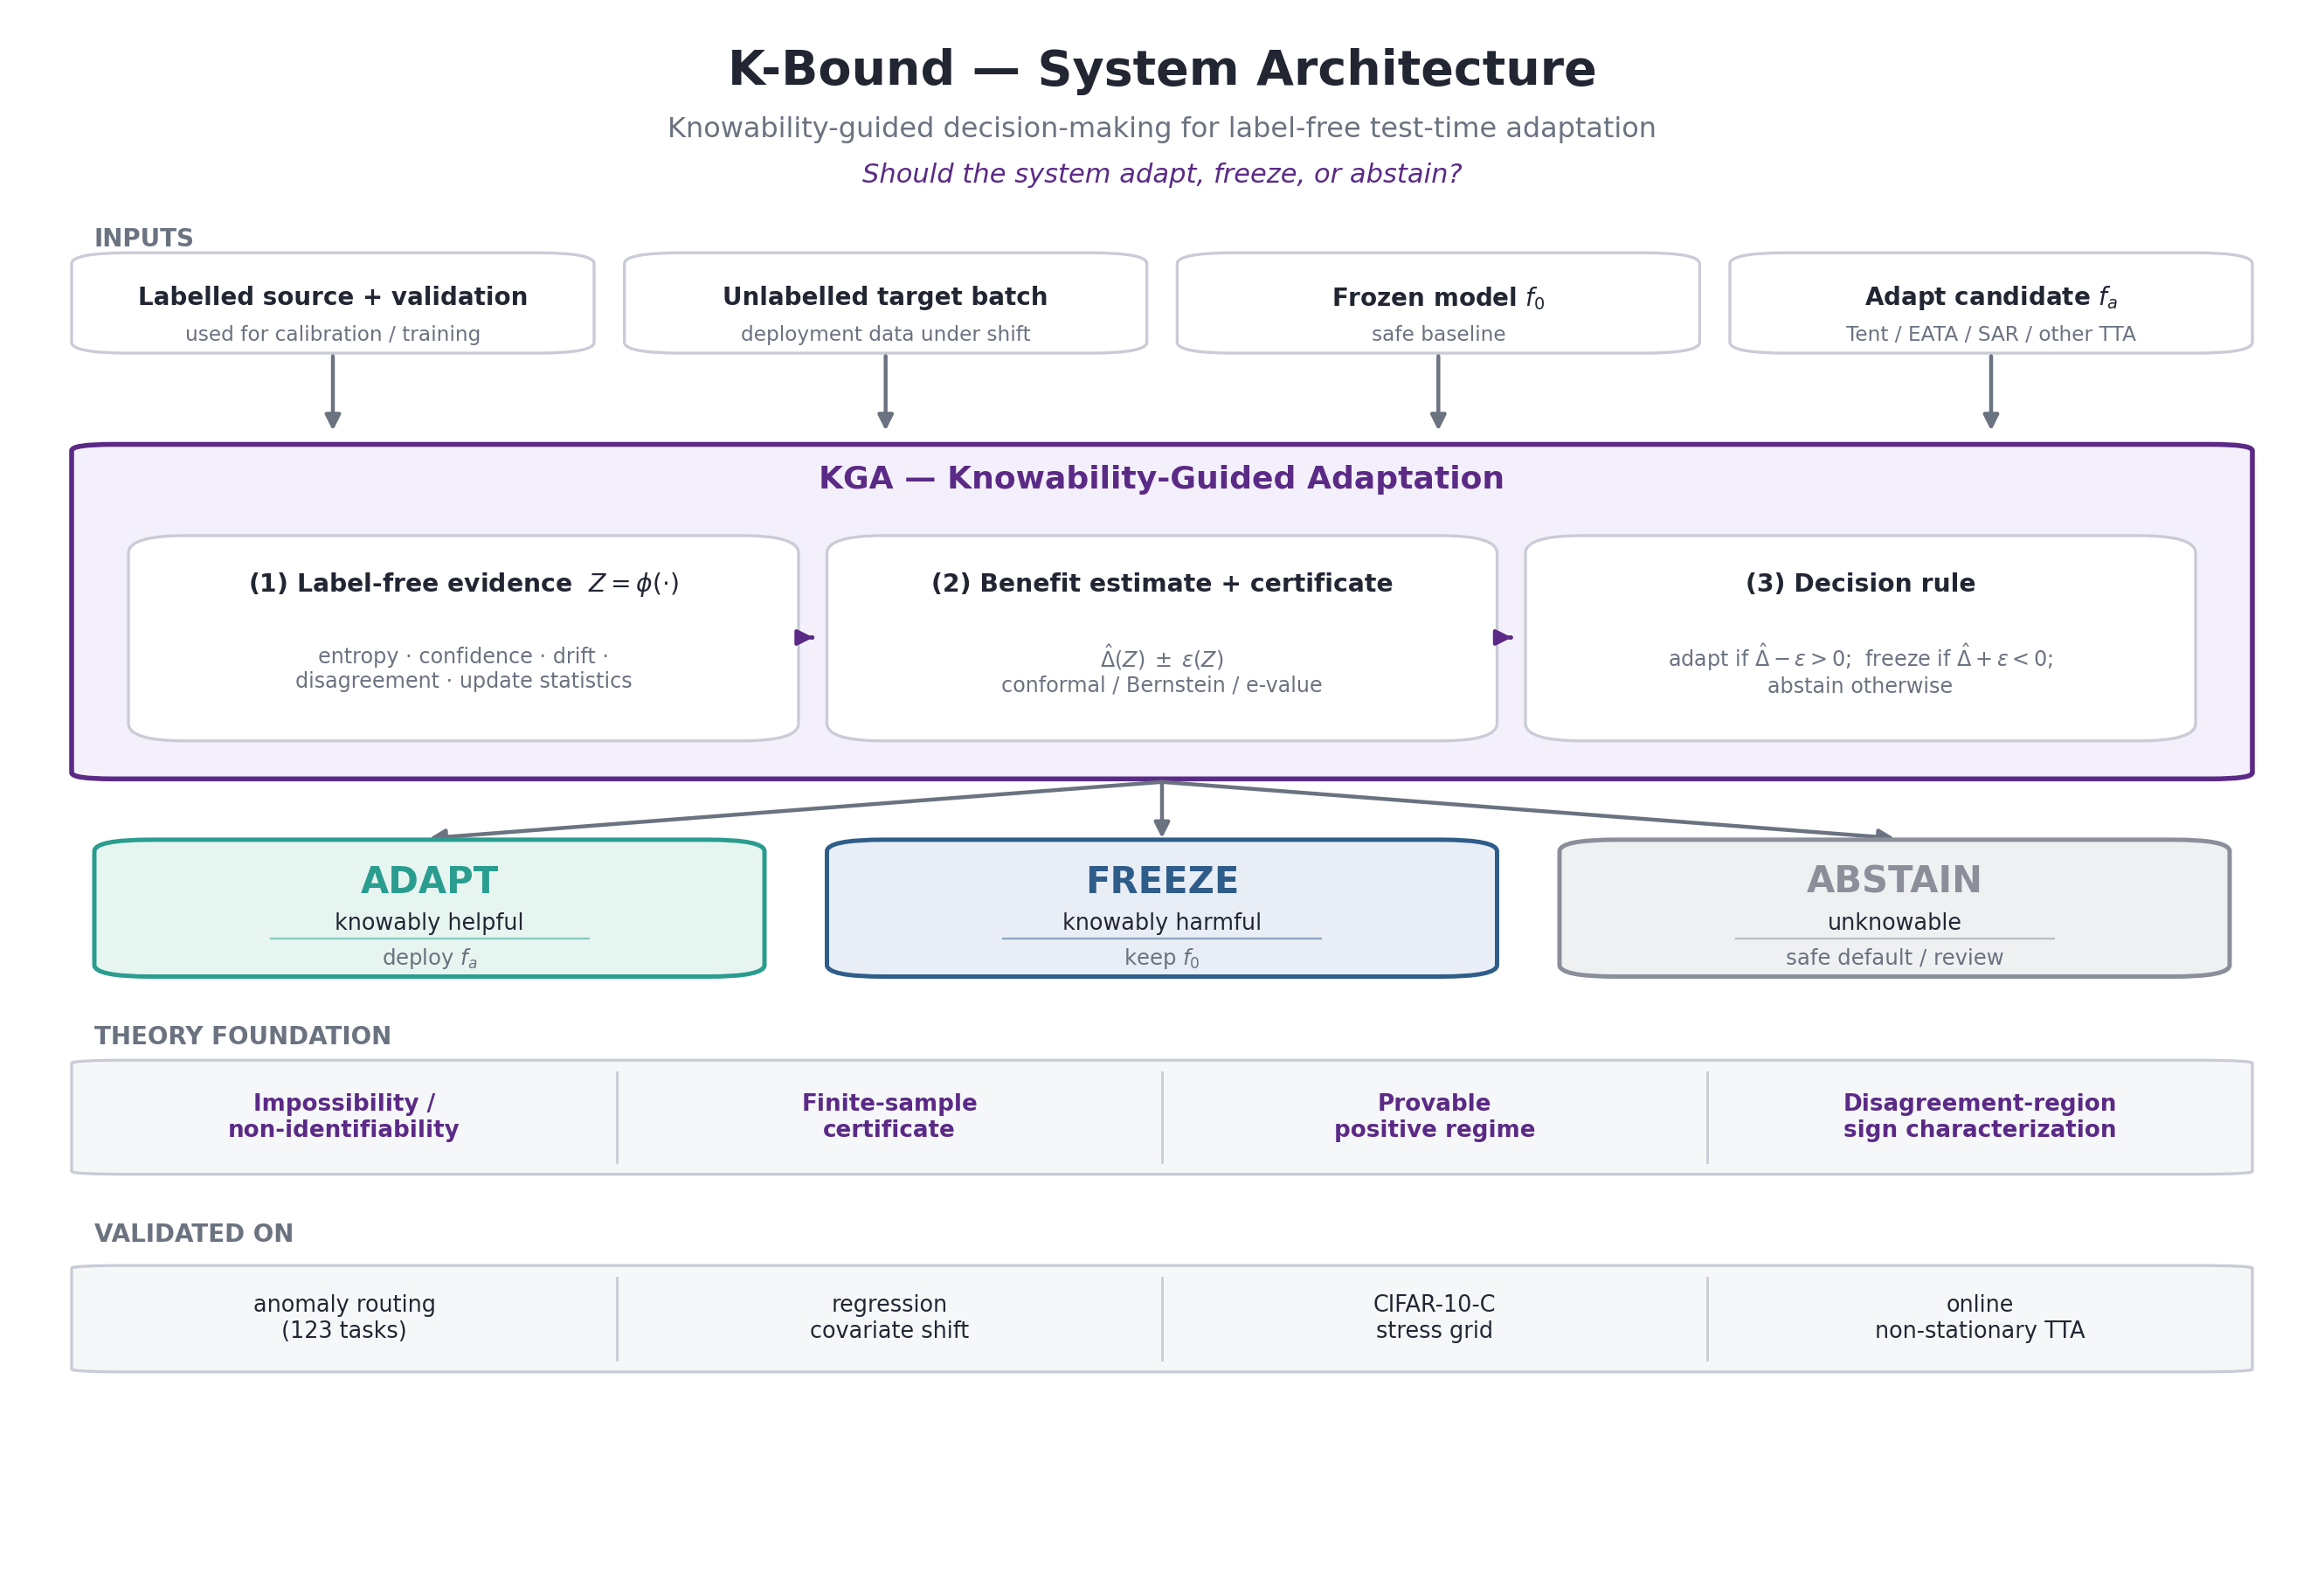

In [3]:
fig('fig_architecture.png',860)